In [1]:
import pandas as pd
import zipfile

with zipfile.ZipFile('../Data_Folder/Large_AML_CSV.zip') as z:
    csv_files = sorted([f for f in z.namelist() if f.endswith('.CSV')])
    first_file = csv_files[0]
    print(f"Opening: {first_file}")
    with z.open(first_file) as f:
        data = pd.read_csv(f)

display(data)

Opening: CSV/0001.CSV


,FS Lin,SS Log,FL1 Log,FL2 Log,FL3 Log,FL4 Log,FL5 Log
0,427,0.452041,0.140279,0.213405,0.683650,0.160077,0.140279
1,917,0.620252,0.253195,0.276627,0.609630,0.203733,0.257787
2,890,0.620252,0.248659,0.184568,0.592770,0.140279,0.140279
3,855,0.656414,0.246862,0.248659,0.530069,0.167291,0.144721
4,921,0.629973,0.212638,0.265240,0.598100,0.212638,0.162236
...,...,...,...,...,...,...,...
26961,476,0.407580,0.140279,0.140279,0.723941,0.140279,0.140279
26962,402,0.419988,0.140279,0.140279,0.705563,0.140279,0.218876
26963,388,0.374723,0.149134,0.196743,0.668724,0.140279,0.140279
26964,473,0.452976,0.140279,0.140279,0.723941,0.216509,0.142424


In [2]:
import pandas as pd
import zipfile

with zipfile.ZipFile('../Data_Folder/Large_AML_CSV.zip') as z:
    csv_files = sorted([f for f in z.namelist() if f.endswith('.CSV')])
    # Select the second file in the list (index 1) for Tube 2
    second_file = csv_files[1] 
    print(f"Opening: {second_file}")
    with z.open(second_file) as f:
        data = pd.read_csv(f)

display(data)

Opening: CSV/0002.CSV


,FS Lin,SS Log,FL1 Log,FL2 Log,FL3 Log,FL4 Log,FL5 Log
0,830,0.628206,0.456709,0.455776,0.594547,0.153721,0.214176
1,391,0.437027,0.165403,0.172269,0.652014,0.140279,0.140279
2,571,0.646730,0.485412,0.473423,0.458573,0.149808,0.160077
3,961,0.629090,0.321599,0.375697,0.592770,0.205907,0.140279
4,866,0.624672,0.371797,0.459504,0.613173,0.188885,0.140279
...,...,...,...,...,...,...,...
27179,799,0.614058,0.533683,0.540897,0.544498,0.140279,0.151542
27180,732,0.651133,0.495506,0.505559,0.563341,0.165870,0.140279
27181,400,0.440792,0.140279,0.221275,0.668724,0.140279,0.140279
27182,872,0.614944,0.429474,0.466011,0.603425,0.232873,0.203017


In [3]:
labels = pd.read_csv('../Data_Folder/Class_Labels.csv')
print(labels.head())
print(labels.columns.tolist())
print(labels['Label'].unique())

   FCSFileName  TubeNumber  SampleNumber   Label
0            1           1             1  normal
1            2           2             1  normal
2            3           3             1  normal
3            4           4             1  normal
4            5           5             1  normal
['FCSFileName', 'TubeNumber', 'SampleNumber', 'Label']
<StringArray>
['normal', 'aml', nan]
Length: 3, dtype: str


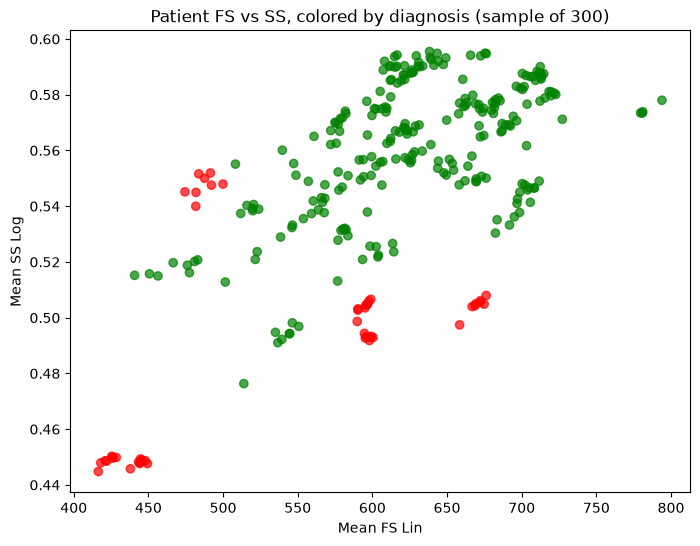

Plotted 300 patients (48 AML, 252 normal)


In [4]:
import pandas as pd
import zipfile
import matplotlib.pyplot as plt

SAMPLE_SIZE = 300  # adjust this number as needed

# Loop through a limited sample of patient CSVs
results = []
with zipfile.ZipFile('../Data_Folder/Large_AML_CSV.zip') as z:
    csv_files = sorted([f for f in z.namelist() if f.endswith('.CSV')])
    csv_files = csv_files[:SAMPLE_SIZE]  # only process the first N files
    for filename in csv_files:
        with z.open(filename) as f:
            df = pd.read_csv(f)
        patient_id = int(filename.split('/')[-1].replace('.CSV', ''))
        results.append({
            'FCSFileName': patient_id,
            'mean_FS': df['FS Lin'].mean(),
            'mean_SS': df['SS Log'].mean()
        })

summary = pd.DataFrame(results)
summary = summary.merge(labels, on='FCSFileName')
summary = summary.dropna(subset=['Label'])

colors = summary['Label'].map({'normal': 'green', 'aml': 'red'})

# Plot FS vs. SS with colors based on diagnosis
plt.figure(figsize=(8,6))
plt.scatter(summary['mean_FS'], summary['mean_SS'], c=colors, alpha=0.7)
plt.xlabel('Mean FS Lin')
plt.ylabel('Mean SS Log')
plt.title(f'Patient FS vs SS, colored by diagnosis (sample of {SAMPLE_SIZE})')
plt.show()

print(f"Plotted {len(summary)} patients ({(summary['Label']=='aml').sum()} AML, {(summary['Label']=='normal').sum()} normal)")